In [40]:
import pandas as pd

In [41]:
df=pd.read_csv("student_info.csv")

In [42]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [43]:
x=df[['study_hours']]

In [44]:
x

,study_hours
0,6.83
1,6.56
2,NaN
3,5.67
4,8.67
...,...
195,7.53
196,8.56
197,8.94
198,6.60


In [45]:
x.isnull().sum()

study_hours    5
dtype: int64

In [46]:
x['study_hours']=x['study_hours'].fillna(x['study_hours'].mean())

In [47]:
x.isnull().sum()

study_hours    0
dtype: int64

In [48]:
y=df[['student_marks']]

In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
from sklearn import linear_model

In [51]:
reg=linear_model.LinearRegression()

reg.fit(x,y)

In [52]:
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
reg.coef_

array([[3.89645241]])

In [54]:
reg.intercept_

array([50.67436878])

In [55]:
import matplotlib.pyplot as plt

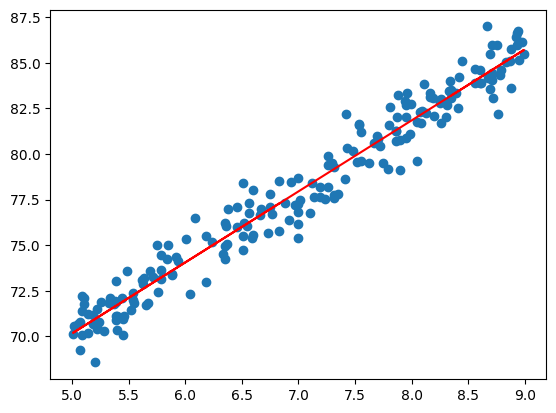

In [56]:

plt.scatter(x,y)
plt.plot(x,x*reg.coef_+reg.intercept_,color='red')
plt.show()

In [57]:
reg.predict(pd.DataFrame([[6.83]],columns=['study_hours']))

array([[77.28713872]])

In [58]:
df['study_hours']=x['study_hours'].fillna(df['study_hours'].mean())


In [59]:
df.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [60]:
import numpy as np

In [61]:
hours=[6,6.5,7,8,10,16,24,7,8,4]

In [62]:
hours=pd.DataFrame([6, 6.5, 7, 8, 10, 16, 24, 7, 8, 4])

In [63]:
new_df=pd.DataFrame(reg.predict(hours))

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [64]:
df.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [65]:
print(new_df)

            0
0   74.053083
1   76.001309
2   77.949536
3   81.845988
4   89.638893
5  113.017607
6  144.189227
7   77.949536
8   81.845988
9   66.260178


In [66]:
pred=reg.predict(new_df)
pred=min(pred[0],100)


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
pred

100

In [68]:
new_df=pd.DataFrame(reg.predict(hours),columns=['hours'])


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [69]:
new_df

,hours
0,74.053083
1,76.001309
2,77.949536
3,81.845988
4,89.638893
5,113.017607
6,144.189227
7,77.949536
8,81.845988
9,66.260178


In [70]:
new_df

,hours
0,74.053083
1,76.001309
2,77.949536
3,81.845988
4,89.638893
5,113.017607
6,144.189227
7,77.949536
8,81.845988
9,66.260178


In [ ]:
new_df.to_csv('predicted.csv')

In [ ]:
reg.predict([[10]])

In [78]:
import pickle


In [80]:
pickle.dump(reg, open("ml_model.pkl", "wb"))

In [85]:
def marks_predict(hours):
    return reg.predict([[hours]])

In [82]:
reg.predict([[10]])

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[89.63889285]])

In [86]:
print(marks_predict(10))

[[89.63889285]]


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
